# Business Questions

 1. Which products generate the most revenue?
 2. Which countries contribute the most to sales?
 3. What is the average amount spent per customer?
 4. What is the seasonal behavior of purchases (most profitable months)?
 5. Which products have the highest return?

## Steps

 1. Importing and Initial Exploration of the Dataset
 2. Data Cleaning (null values, duplicates, inconsistencies and extreme values) and Exploratory Data Analysis (EDA)
 3. Data Visualization and answering the Business Questions.

# Step 1. Importing and Initial Exploration of the Dataset

In [4]:
# Imports.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import numpy as np

In [5]:
# Importing and reading excel file.

df = pd.read_excel('online_retail.xlsx')

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
# Check for null values on each column.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
# Count null values on each column.

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# Check for inconsistent values on each column.

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


It seems that we have very high "max" and very low "min"values on the "Quantity" column. We should check them later on for outliers.

Also, we shouldn't have negative values on unitPrice. Negative values on "Quantity" can represent return. This information should be confirmed with the team that registries the values on the spreadsheet or consulting the database organization.

Let's investigate it further.

In [11]:
# Let's take a look at only cases with negative quantities 

df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


It seems that it also has some sort of internal code for sales team between StockCode and the operation. For instance, the code "D" seems be beeing used for applying discounts.

Now, let's analyse the negative "UnitPrice".

In [13]:
# Checking negative or zero prices

df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


In [14]:
# Checking null CustomerID on negative or zero prices

df[df['UnitPrice'] <= 0]['CustomerID'].isnull().sum()

2477

It seems that most negative or zero prices are not associated to any customer. Since they do not make sense to us, we can remove them from our analysis in the future.

In [16]:
# Count duplicated lines in the dataset.

df.duplicated().sum()

5268

**Diagnostic**: we found (1) null values in two coluns, (2) inconsistent values in another two (in this case, negative values on quantity and price) and (3) 5268 duplicated lines. Let's correct them now.

# Step 2. Data Cleaning (null values, duplicates, inconsistencies and extreme values) and Exploratory Data Analysis (EDA)

### 2.1. Droping columns

We won't be using all columns on the dataset, so we can drop some of them to make our analysis easier and faster.
From the business questions, the useless columns are: "InvoiceNo" and "StockCode"

In [20]:
# Remoing the first two columns

cleaned_df = df.drop(columns=['InvoiceNo','StockCode'])

### 2.2. Null values

We identified null values at two columns: "Description" and "CustomerID". Since the column "Description" will be used for two of our business questions and it represents only ~0.3% of the data, we'll remove them. For CustomerID, we'll keep the null values for now and only remove them when we start analysing this column.

In [22]:
# Removing lines with null values in the column "Description".

cleaned_df = cleaned_df.dropna(subset=['Description'])

In [23]:
# Counting null values again.

cleaned_df.isnull().sum()

Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

We still have null values on the CustomerID column. We wont drop those columns, since it's a considerable portion of our dataset. But we won't drop the column, since the information is usefull for us to answer one of the proposed questions. Thus, we'll keep it as it is and do the cleaning when we start answering the business question that involves customers.

## 2.3. Treating Duplicates

Duplicates can be removed directly, as they can distort our analysis.

In [26]:
# Deleting duplicated rows.

cleaned_df = cleaned_df.drop_duplicates()
cleaned_df.duplicated().sum()

0

## 2.4. Treating Inconsistencies

Inconsistencies can also distort our analysis, since they do not represent anything real or possible (in this case, negative quantities or sales).

We talked to the sales team and they confirmed our hypothesis that the negative quantity values refeer to discounts and refunds. The UnitPrice, however, shouldn't be negative or zero. Thus, we'll remove them now. 

In [28]:
# Removing prices below zero from the dataset.

cleaned_df = cleaned_df[cleaned_df['UnitPrice'] > 0]

## 2.5. Identifying outliers

We noticed that there are some very high and low values on the Quantity column. We should identify the outliers and remove them from the analysis.

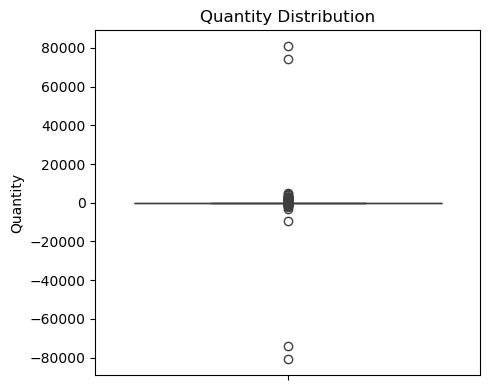

In [30]:
# Plotting the boxplot

plt.figure(figsize=(5, 4))

sns.boxplot(y=cleaned_df['Quantity'])
plt.title('Quantity Distribution')

plt.tight_layout()
plt.show()

The extreme values seems to be complementary: for one in the top, there's one negative. They will not make any difference in the total and will not change the average or median. However, one of the business questions we have to answer do involve the number of itens returned, which means that those values will be considerated. Thus, we should ask the sales team if that's a mistake and if so, remove them from the dataset.
After a meeting with the business unit, I had the confirmation that is indeed a mistake and should be removed.

In [32]:
cleaned_df = cleaned_df[((cleaned_df['Quantity'] > -60000) & (cleaned_df['Quantity'] < 60000))]

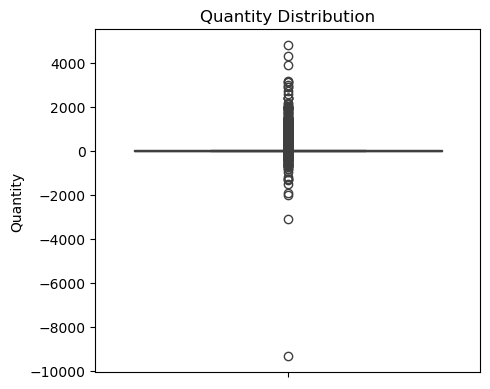

In [33]:
# Plotting the boxplot

plt.figure(figsize=(5, 4))

sns.boxplot(y=cleaned_df['Quantity'])
plt.title('Quantity Distribution')

plt.tight_layout()
plt.show()

# 3. Data Visualization and answering the Business Questions.

Now we start exploring our data to answer our business questions.

## 3.1. Which products generate the most revenue?

In [36]:
# First, we calculate the revenue per sale

cleaned_df['Revenue'] = cleaned_df['Quantity'] * cleaned_df['UnitPrice']

# Then, we group the revenue by product. We also filter it by the top 10 values

product_revenue = cleaned_df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(6)

product_revenue = product_revenue.reset_index().rename(columns={'Description': 'Product'})
product_revenue_raw = product_revenue.iloc[1:]
product_revenue['Revenue'] = product_revenue['Revenue'].apply(lambda x: f"£{x:,.2f}")
product_revenue=product_revenue.iloc[1:]
print('Top 5 Products by Revenue:\n')
display(product_revenue)

Top 5 Products by Revenue:



,Product,Revenue
1,REGENCY CAKESTAND 3 TIER,"£164,459.49"
2,WHITE HANGING HEART T-LIGHT HOLDER,"£99,592.53"
3,PARTY BUNTING,"£98,234.56"
4,JUMBO BAG RED RETROSPOT,"£92,084.93"
5,RABBIT NIGHT LIGHT,"£66,653.37"


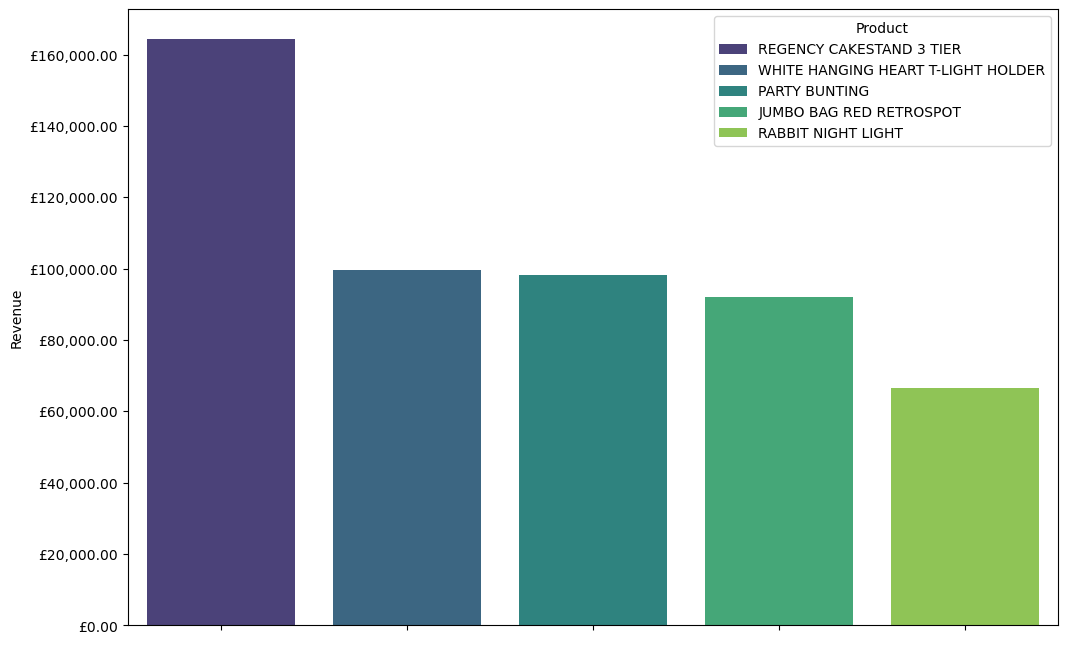

In [37]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Product', y='Revenue', data=product_revenue_raw, palette='viridis', hue='Product',legend=True)
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'£{x:,.2f}'))
plt.xticks(color='w')
plt.xlabel("")

# Save Graph and plot
plt.savefig('01_bar_grapth_products.png')
plt.show()

## (BONUS) 3.1.2. What was the total revenue?

If we look at the dataset as a whole, we'll notice that there are some expenses registered on it as negative values.

In [39]:
cleaned_df['Revenue'] = cleaned_df['Quantity'] * cleaned_df['UnitPrice']

# Then, we group the revenue by product. We also filter it by the top 10 values

product_revenue = cleaned_df.groupby('Description')['Revenue'].sum().sort_values(ascending=True).head(20)

product_revenue = product_revenue.reset_index().rename(columns={'Description': 'Product'})
product_revenue['Revenue'] = product_revenue['Revenue'].apply(lambda x: f"£{x:,.2f}")
display(product_revenue)

,Product,Revenue
0,AMAZON FEE,"£-221,520.50"
1,Manual,"£-69,031.64"
2,CRUK Commission,"£-7,933.43"
3,Bank Charges,"£-7,175.64"
4,Discount,"£-5,696.22"
5,SAMPLES,"£-3,039.65"
6,WHITE CHERRY LIGHTS,£-54.00
7,CREAM SWEETHEART MAGAZINE RACK,£-46.85
8,WOODEN BOX ADVENT CALENDAR,£-45.70
9,ASSORTED TUTTI FRUTTI ROUND BOX,£-39.60


Thus, we should remove them before calculating the total revenue. We should only have negative values to products.

In [41]:
cleaned_df_new = cleaned_df[~cleaned_df['Description'].isin(['POSTAGE','DOTCOM POSTAGE','AMAZON FEE', 'Manual', 'CRUK Commission', 'Bank Charges', 'Discount', 'SAMPLES'])]

In [42]:
total_revenue = cleaned_df_new['Revenue'].sum()
print(f'Total revenue was £{total_revenue:,.2f}')

Total revenue was £9,784,195.77


## 3.2. Which countries contribute the most to sales?

In [44]:
# Since we already calculated the revenue before, no need to recalculate it.
# We just have to aggregate the revenue by country.

country_revenue = cleaned_df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_revenue = country_revenue.reset_index()
total_revenue = country_revenue['Revenue'].sum()
country_revenue['% of total'] = round((100*country_revenue['Revenue']/total_revenue),2)
country_revenue['Revenue'] = country_revenue['Revenue'].apply(lambda x: f"£{x:,.2f}")
country_revenue.index += 1
print("Top 10 Countries by Revenue:\n")
display(country_revenue.head(10))

Top 10 Countries by Revenue:



,Country,Revenue,% of total
1,United Kingdom,"£8,183,414.44",84.00
2,Netherlands,"£284,661.54",2.92
3,EIRE,"£262,993.38",2.70
4,Germany,"£221,491.47",2.27
5,France,"£197,317.11",2.03
6,Australia,"£137,009.77",1.41
7,Switzerland,"£56,363.05",0.58
8,Spain,"£54,756.03",0.56
9,Belgium,"£40,910.96",0.42
10,Sweden,"£36,585.41",0.38


##  3.3. What is the average amount spent per customer?

For this question, we need to discard the null values previously kept on the dataset in the column CustomerID.

In [46]:
# First, we drop lines with null values in the CustomerID column

cleaned_df_not_null = cleaned_df.dropna(subset=['CustomerID'])

# Then, we can group the revenue by CustomerID and then calculate the mean

total_revenue_per_customer = cleaned_df_not_null.groupby('CustomerID')['Revenue'].sum()
average_spent_per_customer = total_revenue_per_customer.mean()


print("Average amount spent per customer:", average_spent_per_customer)

Average amount spent per customer: 1894.028623340961


## 3.4. What is the seasonal behavior of purchases (most profitable months)?

In [48]:
# In this case, we'll analyse only results per month. So, the best way to do it is by summing all the revenue in each month and plotting it. 

cleaned_df['Month'] = cleaned_df['InvoiceDate'].dt.month
monthly_revenue = cleaned_df.groupby('Month')['Revenue'].sum()
monthly_revenue = monthly_revenue.reset_index()
old_monthly = monthly_revenue.copy()
total_monthly_revenue = monthly_revenue['Revenue'].sum()
monthly_revenue['% of total'] = round((100*monthly_revenue['Revenue']/total_monthly_revenue),1)
monthly_revenue['Revenue'] = monthly_revenue['Revenue'].apply(lambda x: f"£{x:,.2f}")
monthly_revenue.index += 1

print("Monthly Revenue:\n")
display(monthly_revenue.head(12))

Monthly Revenue:



,Month,Revenue,% of total
1,1,"£558,310.17",5.7
2,2,"£496,770.07",5.1
3,3,"£681,290.63",7.0
4,4,"£491,909.12",5.0
5,5,"£720,945.53",7.4
6,6,"£689,382.52",7.1
7,7,"£678,953.65",7.0
8,8,"£703,500.58",7.2
9,9,"£1,017,377.11",10.4
10,10,"£1,069,258.07",11.0


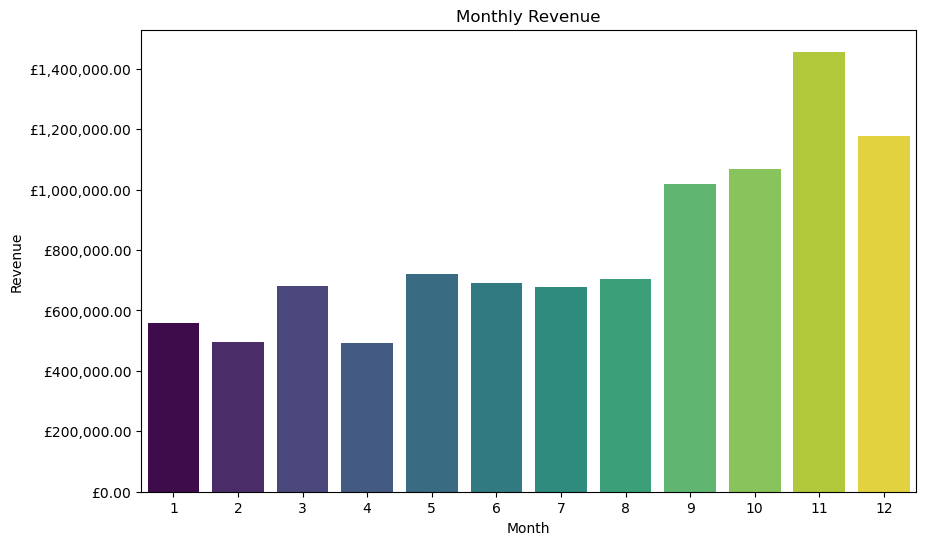

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Revenue', data=old_monthly, palette='viridis', hue='Month',legend=False)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'£{x:,.2f}'))

# Rodar o gráfico
plt.savefig('02_bar_grapth_seasonal.png')
plt.show()


## 3.5. Which products have the highest return?

In [51]:
product_returns = cleaned_df[
    (cleaned_df['Quantity'] < 0) &
    (~cleaned_df['Description'].isin(['POSTAGE','DOTCOM POSTAGE','AMAZON FEE', 'Manual', 'CRUK Commission', 'Bank Charges', 'Discount', 'SAMPLES']))
]
product_returns=product_returns[['Description','Quantity']].reset_index(drop=True)

total_quantity_sold = cleaned_df[
    (cleaned_df['Quantity'] > 0) &
    (~cleaned_df['Description'].isin(['Manual', 'POSTAGE', 'Discount', 'SAMPLES']))
].groupby('Description')['Quantity'].sum().reset_index()
total_quantity_returned = product_returns.groupby('Description')['Quantity'].sum().reset_index()
total_quantity_returned['Quantity'] = np.abs(total_quantity_returned['Quantity'])
product_return_rates = pd.merge(total_quantity_returned, total_quantity_sold, on='Description', how='left')
product_return_rates.rename(columns={'Quantity_x': 'Total Returned', 'Quantity_y': 'Total Sold'}, inplace=True)
product_return_rates['Return rate (%)'] = round((100*product_return_rates['Total Returned'] / product_return_rates['Total Sold']), 2)
product_return_rates = product_return_rates.sort_values(by='Return rate (%)',ascending=False)
product_return_rates = product_return_rates[product_return_rates['Return rate (%)'] <= 100]
product_return_rates['Total Sold'] = product_return_rates['Total Sold'].astype(int)
product_return_rates = product_return_rates[product_return_rates['Total Sold'] >= 100].reset_index(drop=True)
product_return_rates.index += 1
product_return_rates.rename(columns={'Description':'Product'}, inplace=True)
print("\nProducts with Highest Returns:")
display(product_return_rates.head(10))


Products with Highest Returns:


,Product,Total Returned,Total Sold,Return rate (%)
1,ROTATING SILVER ANGELS T-LIGHT HLDR,9376,9459,99.12
2,SET OF 3 BABUSHKA STACKING TINS,255,274,93.07
3,PANTRY CHOPPING BOARD,946,1154,81.98
4,IVORY CHANDELIER T-LIGHT HOLDER,432,657,65.75
5,BEADED CHANDELIER T-LIGHT HOLDER,433,695,62.30
6,FLOWERS CHANDELIER T-LIGHT HOLDER,579,960,60.31
7,TEA TIME PARTY BUNTING,1424,2574,55.32
8,HERB MARKER BASIL,1527,3423,44.61
9,MIRROR MOSAIC T-LIGHT HOLDER,720,1622,44.39
10,OFFICE MUG WARMER PINK,250,565,44.25


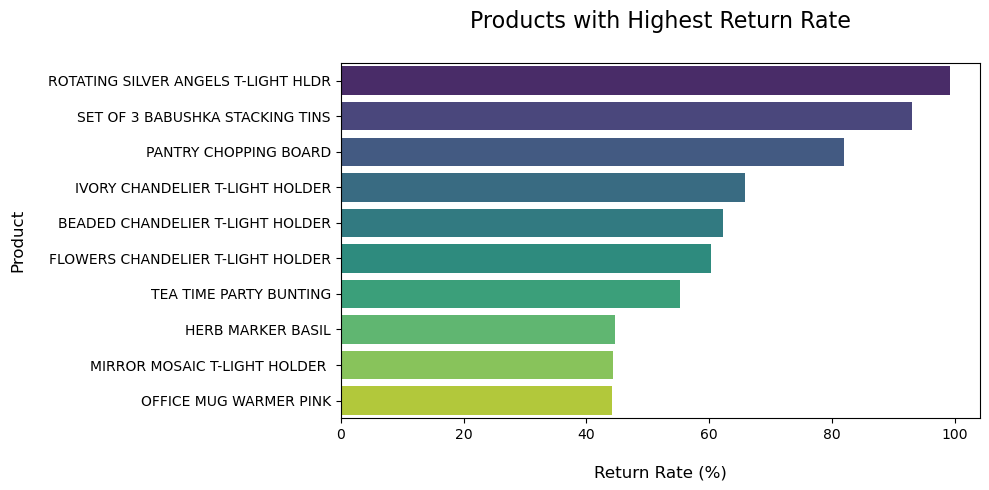

In [52]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=product_return_rates.head(10), 
    x='Return rate (%)', 
    y='Product', 
    palette='viridis',
    hue ='Product',
    legend= False
)

plt.title('Products with Highest Return Rate\n', fontsize=16)
plt.xlabel('\nReturn Rate (%)', fontsize=12)
plt.ylabel('Product\n', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('03_bar_graph_return_rate.png')
plt.show()